<a href="https://colab.research.google.com/github/UROOJKHANdev/ARTIFICIAL-AND-DATA-SCIENCE-MODELS-/blob/main/K-NEAREST%20NEIGHBORS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv('/content/AIML Dataset.csv')
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
165434,12,PAYMENT,4149.07,C2001802076,0.0,0.00,M1708280162,0.0,0.0,0.0,0.0
165435,12,PAYMENT,20934.94,C150264052,0.0,0.00,M806755072,0.0,0.0,0.0,0.0
165436,12,CASH_OUT,122832.41,C1327637933,23958.0,0.00,C475670359,11507.0,0.0,0.0,0.0
165437,12,CASH_IN,424626.95,C944569458,58972.0,483598.95,C929611695,0.0,0.0,0.0,0.0


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [6]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
165434,12,PAYMENT,4149.07,C2001802076,0.0,0.00,M1708280162,0.0,0.0,0.0,0.0
165435,12,PAYMENT,20934.94,C150264052,0.0,0.00,M806755072,0.0,0.0,0.0,0.0
165436,12,CASH_OUT,122832.41,C1327637933,23958.0,0.00,C475670359,11507.0,0.0,0.0,0.0
165437,12,CASH_IN,424626.95,C944569458,58972.0,483598.95,C929611695,0.0,0.0,0.0,0.0
165438,12,PAYMENT,35864.56,C382841079,63909.0,28044.44,M,NaN,NaN,NaN,NaN


In [7]:
df.shape

(165439, 11)

In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [9]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165439 entries, 0 to 165438
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            165439 non-null  int64  
 1   type            165439 non-null  object 
 2   amount          165439 non-null  float64
 3   nameOrig        165439 non-null  object 
 4   oldbalanceOrg   165439 non-null  float64
 5   newbalanceOrig  165439 non-null  float64
 6   nameDest        165439 non-null  object 
 7   oldbalanceDest  165438 non-null  float64
 8   newbalanceDest  165438 non-null  float64
 9   isFraud         165438 non-null  float64
 10  isFlaggedFraud  165438 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 13.9+ MB


In [11]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,165439.000000,1.654390e+05,1.654390e+05,1.654390e+05,1.654380e+05,1.654380e+05,165438.000000,165438.0
mean,9.553715,1.793496e+05,8.862403e+05,9.031748e+05,9.229948e+05,1.185652e+06,0.000804,0.0
std,1.967747,3.360318e+05,2.812176e+06,2.848990e+06,2.380862e+06,2.690358e+06,0.028342,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.000000,1.141030e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,10.000000,6.376490e+04,1.951200e+04,0.000000e+00,3.956590e+04,1.070278e+05,0.000000,0.0
75%,11.000000,2.248438e+05,1.901025e+05,2.227964e+05,7.106599e+05,1.144234e+06,0.000000,0.0
max,12.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.894623e+07,3.904248e+07,1.000000,0.0


In [12]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [13]:
# Remove rows where target is missing
df = df.dropna(subset=['isFraud'])

# Drop unnecessary ID columns
df = df.drop(columns=['nameOrig', 'nameDest'])



In [14]:
print(df.isnull().sum())

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


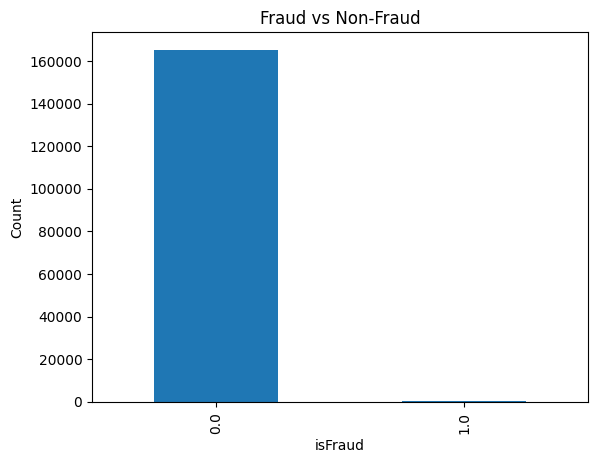

In [15]:
import matplotlib.pyplot as plt

# Fraud Distribution
df['isFraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.show()

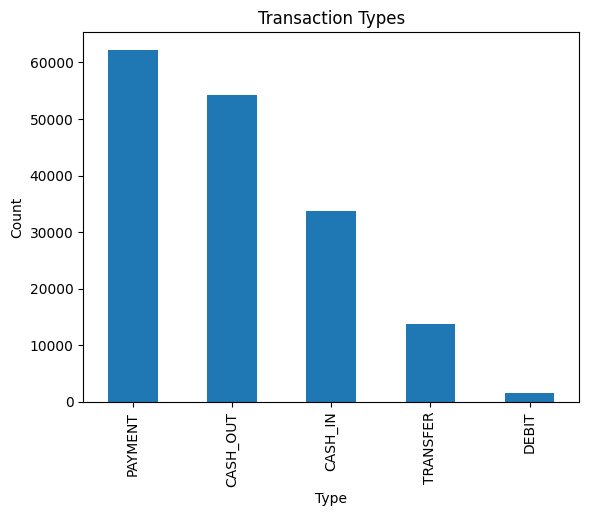

In [16]:
# Transaction Type Distribution
df['type'].value_counts().plot(kind='bar')
plt.title("Transaction Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

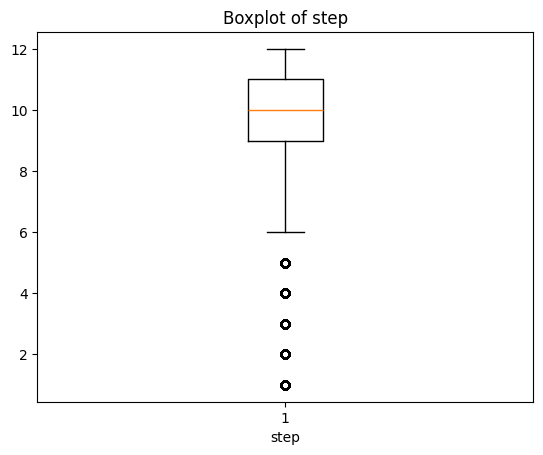

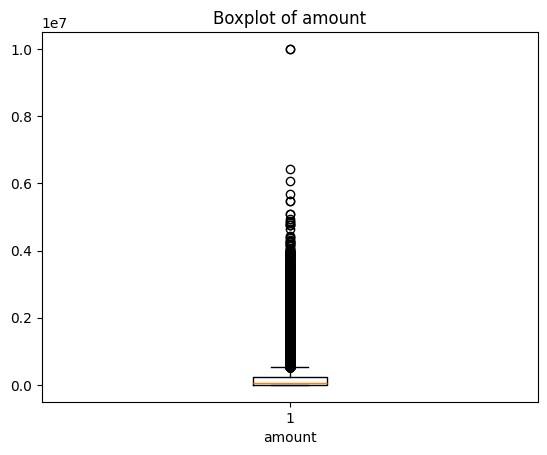

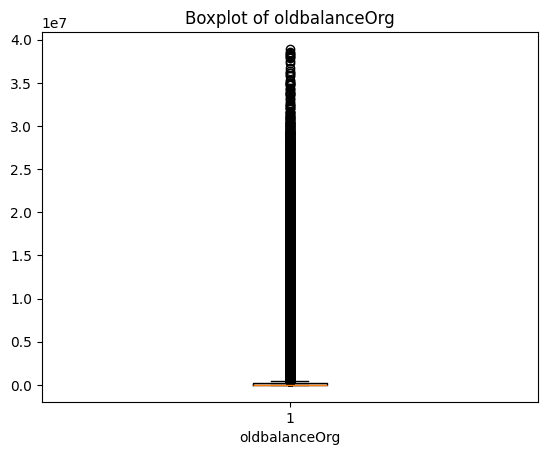

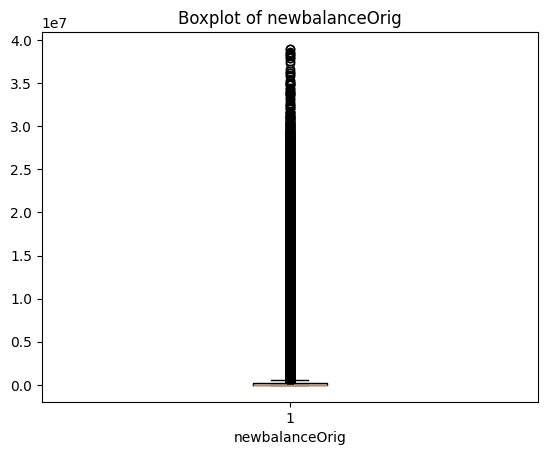

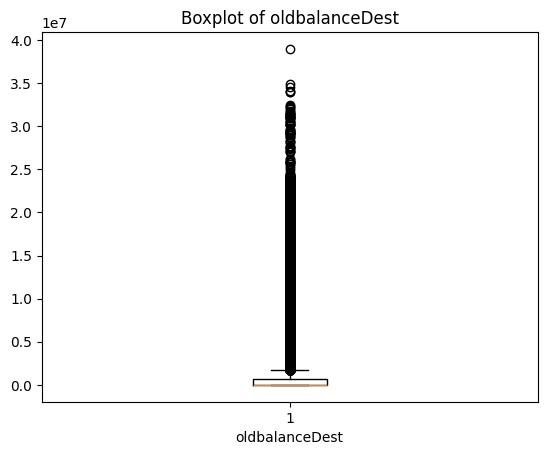

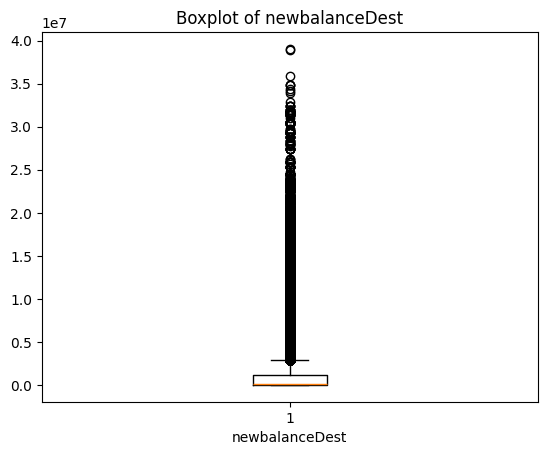

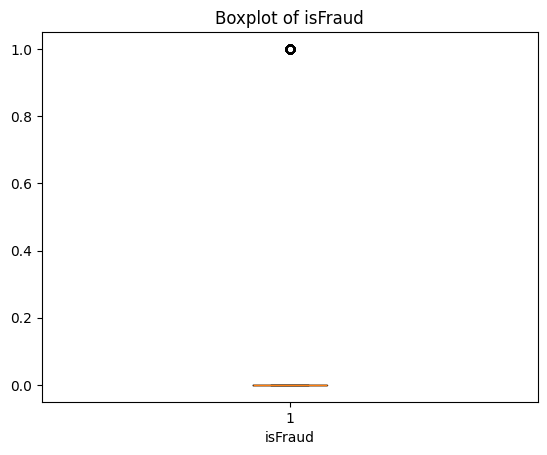

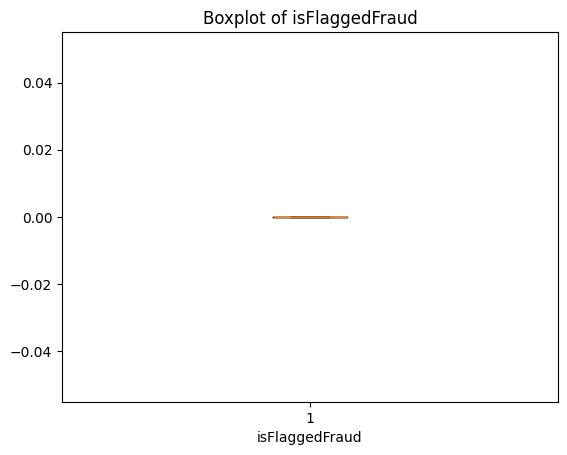

In [17]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [18]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

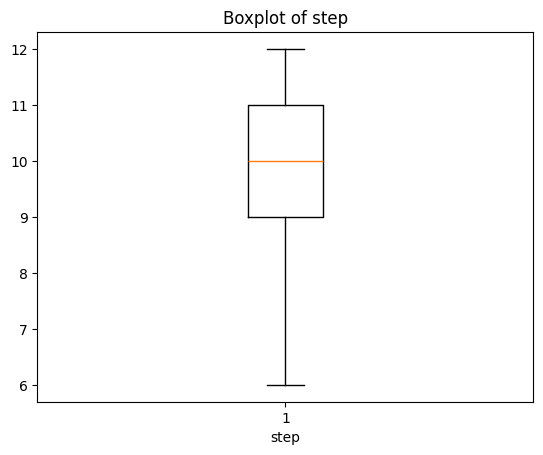

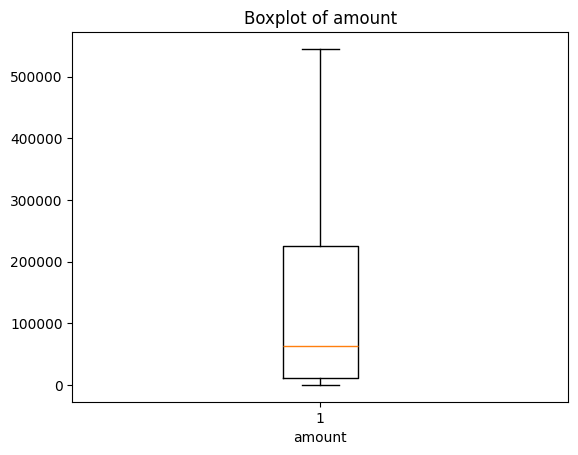

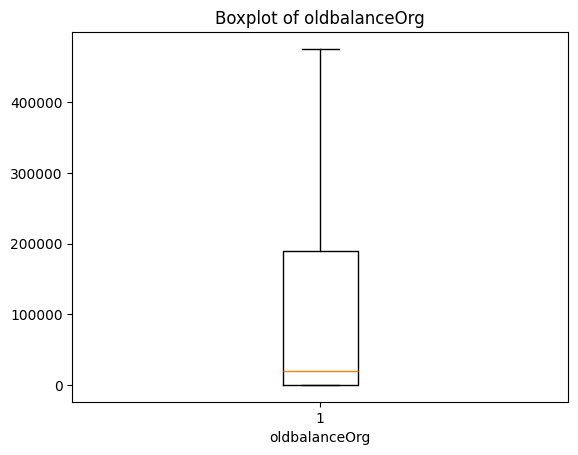

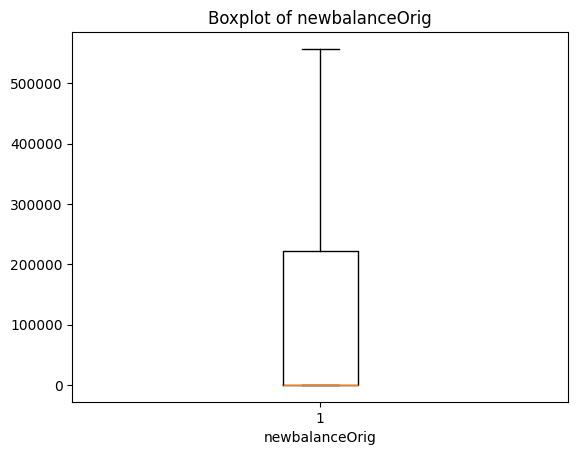

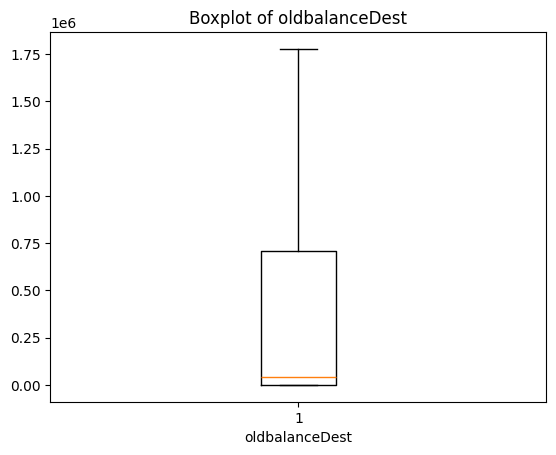

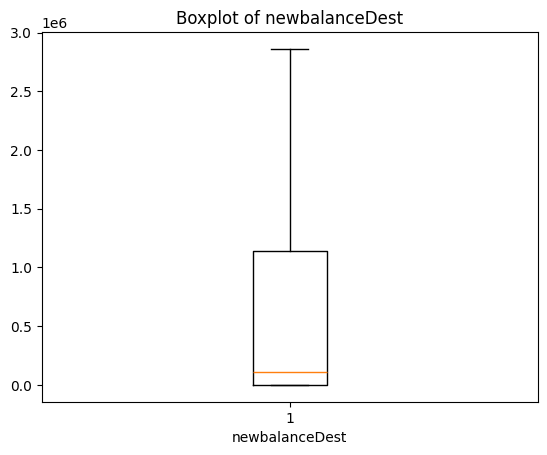

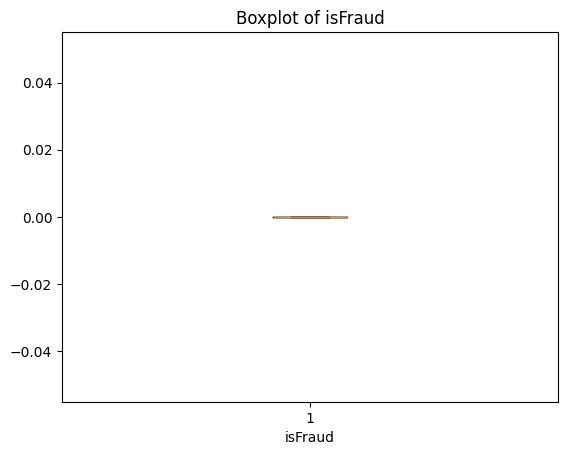

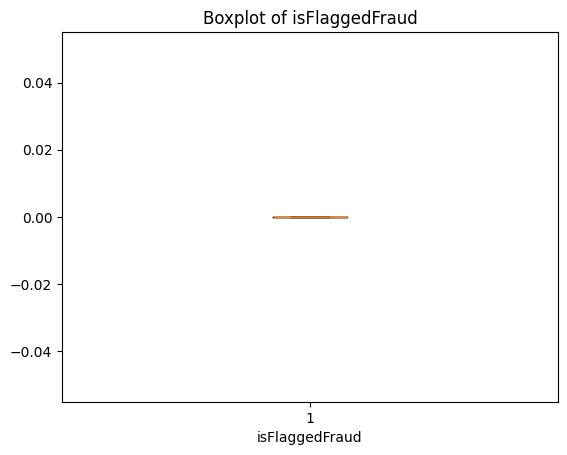

In [19]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['type'] = encoder.fit_transform(df['type'])

print(df.head())


   step  type    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     6     3   9839.64       170136.0       160296.36             0.0   
1     6     3   1864.28        21249.0        19384.72             0.0   
2     6     4    181.00          181.0            0.00             0.0   
3     6     1    181.00          181.0            0.00         21182.0   
4     6     3  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  isFraud  isFlaggedFraud  
0             0.0      0.0             0.0  
1             0.0      0.0             0.0  
2             0.0      0.0             0.0  
3             0.0      0.0             0.0  
4             0.0      0.0             0.0  


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(132350, 8)
(33088, 8)


In [22]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model.fit(X_train, y_train)

KNeighborsClassifier()

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix
[[33088]]

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     33088

    accuracy                           1.00     33088
   macro avg       1.00      1.00      1.00     33088
weighted avg       1.00      1.00      1.00     33088



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [1. 1. 1. 1. 1.]
Average Accuracy: 1.0
